<a href="https://colab.research.google.com/github/isaakcueva/arboles-decision-retraso-vuelos/blob/main/%C3%81rboles_de_Decisi%C3%B3n_Retraso_de_vuelos_IC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarea: Árboles de Decisión - Retraso de vuelos

# Nombre: Isaac Cueva

# Fecha: 24/04/2025

![Descripción de la imagen](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRP9d63jC144Usqa_NjecnoWcJXV60JuFTJLA&s)

###Google Colab Setup

In [ ]:
# Installing required packages
!pip install pyspark
!pip install findspark

In [ ]:
# PySpark is the Spark API for Python. In this lab, we use PySpark to initialize the spark context.
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession

In [ ]:
# Provides findspark.init() to make pyspark importable as a regular library.
import findspark
findspark.init()

In [ ]:
# Creating a spark context class
sc = SparkContext()

# Creating a spark session
spark = SparkSession \
    .builder \
    .appName("Aplicacion Visualización de Datos") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [ ]:
spark

#TAREAS

1. Descargue el dataset adjunto y cree un dataframe de Apache Spark

In [ ]:
# Cargar el archivo CSV como DataFrame de Spark
flights_df = spark.read.csv("flights-larger.csv", header=True, inferSchema=True)

# Mostrar algunas filas para confirmar
flights_df.show(5)


+---+---+---+-------+------+---+----+------+--------+-----+
|mon|dom|dow|carrier|flight|org|mile|depart|duration|delay|
+---+---+---+-------+------+---+----+------+--------+-----+
| 10| 10|  1|     OO|  5836|ORD| 157|  8.18|      51|   27|
|  1|  4|  1|     OO|  5866|ORD| 466|  15.5|     102|   NA|
| 11| 22|  1|     OO|  6016|ORD| 738|  7.17|     127|  -19|
|  2| 14|  5|     B6|   199|JFK|2248| 21.17|     365|   60|
|  5| 25|  3|     WN|  1675|SJC| 386| 12.92|      85|   22|
+---+---+---+-------+------+---+----+------+--------+-----+
only showing top 5 rows



2. Realice todo el preprocesamiento del dataset que crea conveniente.

   **El diccionario de datos del dataset es el siguiente:**
   

    mon — month (integer between 1 and 12)

    dom — day of month (integer between 1 and 31)

    dow — day of week (integer; 1 = Monday and 7 = Sunday)

    org — origin airport (IATA code)

    mile — distance (miles)

    carrier — carrier (IATA code)

    depart — departure time (decimal hour)

    duration — expected duration (minutes)

    delay — delay (minutes)

Eliminar columnas que no se necesitan

In [ ]:
# Eliminar la columna "flight"
flights_df = flights_df.drop("flight")


Eliminar filas con valores nulos

In [ ]:
# Eliminar filas con valores nulos (por ejemplo, en delay)
flights_df = flights_df.na.drop()


Convierta las unidades de la distancia reemplazando la columna “miles” con una columna “km”.

In [ ]:
from pyspark.sql.functions import round, col

# Crear columna "km" a partir de "mile" y eliminar "mile"
flights_df = flights_df.withColumn("km", round(col("mile") * 1.60934, 2)).drop("mile")


La Federal Aviation Administration (FAA) considera que un vuelo se encuentra retrasado cuando este arriva 15 minutos o más tarde de su tiempo programado. Cree una columna con valores booleanos (1 o 0) para conocer si un vuelo está retrasado o no. Nombre esta nueva columna como “label”:


flights_km = flights_km.withColumn('label', (flights_km.delay >= 15).cast('integer'))

In [ ]:
# Crear la columna "label"
flights_df = flights_df.withColumn("label", (col("delay") >= 15).cast("integer"))


In [ ]:
# Mostrar 5 filas después del preprocesamiento
flights_df.show(5)


+---+---+---+-------+---+------+--------+-----+-------+-----+
|mon|dom|dow|carrier|org|depart|duration|delay|     km|label|
+---+---+---+-------+---+------+--------+-----+-------+-----+
| 10| 10|  1|     OO|ORD|  8.18|      51|   27| 252.67|    1|
|  1|  4|  1|     OO|ORD|  15.5|     102|   NA| 749.95| NULL|
| 11| 22|  1|     OO|ORD|  7.17|     127|  -19|1187.69|    0|
|  2| 14|  5|     B6|JFK| 21.17|     365|   60| 3617.8|    1|
|  5| 25|  3|     WN|SJC| 12.92|      85|   22| 621.21|    1|
+---+---+---+-------+---+------+--------+-----+-------+-----+
only showing top 5 rows



3. Indexe las variables categóricas “carrier” y “org” en valores numéricos indexados: “carrier_idx” y “org_idx”.

In [ ]:
from pyspark.ml.feature import StringIndexer

# Indexar 'carrier'
carrier_indexer = StringIndexer(inputCol="carrier", outputCol="carrier_idx")
flights_df = carrier_indexer.fit(flights_df).transform(flights_df)

# Indexar 'org'
org_indexer = StringIndexer(inputCol="org", outputCol="org_idx")
flights_df = org_indexer.fit(flights_df).transform(flights_df)


In [ ]:
flights_df.select("carrier", "carrier_idx", "org", "org_idx").show(5)


+-------+-----------+---+-------+
|carrier|carrier_idx|org|org_idx|
+-------+-----------+---+-------+
|     OO|        2.0|ORD|    0.0|
|     OO|        2.0|ORD|    0.0|
|     OO|        2.0|ORD|    0.0|
|     B6|        4.0|JFK|    2.0|
|     WN|        3.0|SJC|    5.0|
+-------+-----------+---+-------+
only showing top 5 rows



4. Consolide las siguientes columnas predictoras dentro de una simple columna:

    mon, dom y dow

    carrier_idx (indexed value from carrier)

    org_idx (indexed value from org)

    km

    depart

    duration

In [ ]:
from pyspark.ml.feature import VectorAssembler

# Definir columnas de entrada y salida
input_cols = ["mon", "dom", "dow", "carrier_idx", "org_idx", "km", "depart", "duration"]
assembler = VectorAssembler(inputCols=input_cols, outputCol="features")

# Transformar el DataFrame
flights_df = assembler.transform(flights_df)


In [ ]:
flights_df.select("features", "label").show(5, truncate=False)


+------------------------------------------+-----+
|features                                  |label|
+------------------------------------------+-----+
|[10.0,10.0,1.0,2.0,0.0,252.67,8.18,51.0]  |1    |
|[1.0,4.0,1.0,2.0,0.0,749.95,15.5,102.0]   |NULL |
|[11.0,22.0,1.0,2.0,0.0,1187.69,7.17,127.0]|0    |
|[2.0,14.0,5.0,4.0,2.0,3617.8,21.17,365.0] |1    |
|[5.0,25.0,3.0,3.0,5.0,621.21,12.92,85.0]  |1    |
+------------------------------------------+-----+
only showing top 5 rows



5. Divida los datos en dos componentes: training data y testing data con un radio de 80 a 20.

In [ ]:
flights_df = flights_df.na.drop(subset=['label'])

# Dividir los datos en entrenamiento (80%) y prueba (20%)
train_data, test_data = flights_df.randomSplit([0.8, 0.2], seed=1234)

# Verificar las cantidades de datos en cada conjunto
print(f"Datos de entrenamiento: {train_data.count()}")
print(f"Datos de prueba: {test_data.count()}")


Datos de entrenamiento: 206877
Datos de prueba: 51412


6. Construya un árbol de decisión para predecir el retraso de los vuelos (variable 'label').

- Crear el modelo

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier

# Crear el clasificador de árbol de decisión
dt_classifier = DecisionTreeClassifier(labelCol="label", featuresCol="features")

# Entrenar el modelo con los datos de entrenamiento
dt_model = dt_classifier.fit(train_data)


- Hacer predicciones sobre el conjunto de prueba

In [ ]:
# Hacer predicciones en los datos de prueba
predictions = dt_model.transform(test_data)

# Mostrar las primeras 5 predicciones
predictions.select("features", "label", "prediction").show(5, truncate=False)


+-----------------------------------------+-----+----------+
|features                                 |label|prediction|
+-----------------------------------------+-----+----------+
|[0.0,1.0,2.0,1.0,2.0,3983.12,9.0,385.0]  |0    |0.0       |
|[0.0,1.0,2.0,1.0,2.0,4161.75,15.5,386.0] |0    |1.0       |
|[0.0,1.0,2.0,1.0,3.0,1224.71,16.08,160.0]|0    |1.0       |
|[0.0,1.0,2.0,1.0,3.0,1765.45,17.08,190.0]|1    |1.0       |
|[0.0,1.0,2.0,1.0,3.0,1528.87,17.98,170.0]|1    |1.0       |
+-----------------------------------------+-----+----------+
only showing top 5 rows



7. Evalúe su árbol de decisión para lo cual deberá crear una matriz de confusión. Dibuje la matriz de confusión.

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql.types import DoubleType

# Cast 'prediction' and 'label' columns to DoubleType before creating RDD
predictions = predictions.withColumn("prediction", predictions["prediction"].cast(DoubleType()))
predictions = predictions.withColumn("label", predictions["label"].cast(DoubleType()))

# Convertimos a RDD los datos de predicciones (label, prediction)
predictionAndLabels = predictions.select("prediction", "label").rdd.map(tuple)

# Creamos el objeto de métricas
metrics = MulticlassMetrics(predictionAndLabels)

# Obtenemos la matriz de confusión
conf_matrix = metrics.confusionMatrix().toArray()
print(conf_matrix)

/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


[[16602.  8862.]
 [ 9956. 15992.]]


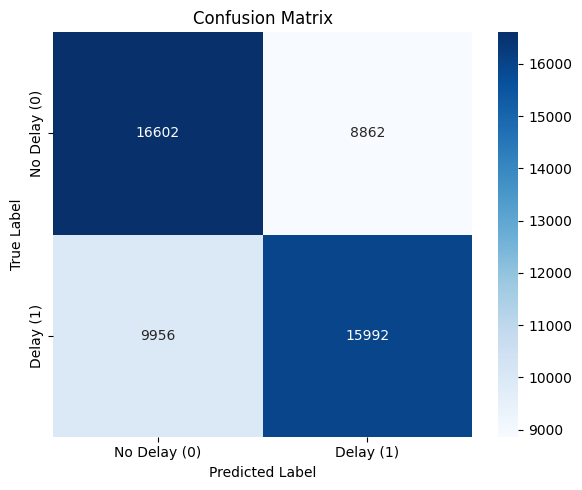

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Etiquetas de clases (puedes cambiarlas según tu contexto)
labels = ["No Delay (0)", "Delay (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="g", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


8. Calcular: accuracy, precision, recall, y F1-score.

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql.types import DoubleType

# Aseguramos tipos correctos
predictions = predictions.withColumn("prediction", predictions["prediction"].cast(DoubleType()))
predictions = predictions.withColumn("label", predictions["label"].cast(DoubleType()))

# Convertimos a RDD
predictionAndLabels = predictions.select("prediction", "label").rdd.map(tuple)
metrics = MulticlassMetrics(predictionAndLabels)

# Métricas generales (ponderadas)
accuracy = metrics.accuracy
weighted_precision = metrics.weightedPrecision
weighted_recall = metrics.weightedRecall
weighted_f1 = metrics.weightedFMeasure()

# Mostrar métricas
print(f"Accuracy:              {accuracy:.4f}")
print(f"Weighted Precision:    {weighted_precision:.4f}")
print(f"Weighted Recall:       {weighted_recall:.4f}")
print(f"Weighted F1-score:     {weighted_f1:.4f}")


/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Accuracy:              0.6340
Weighted Precision:    0.6344
Weighted Recall:       0.6340
Weighted F1-score:     0.6339


9. ¿El modelo es adecuado o no? Justifique su respuesta.

El modelo tiene un desempeño moderado, con métricas como la precisión, el recall y el F1-score ponderados alrededor del 63%. Aunque estos resultados indican que el modelo está funcionando de manera razonable, esta acertando en 63 predicciones de 100, lo que no es lo suficientemente altos como para considerarlo óptimo, especialmente en contextos donde se requiere mayor precisión o donde las decisiones basadas en el modelo pueden tener un impacto significativo como los viajes. Por lo tanto, el modelo podría necesitar mejoras, ya sea mediante ajustes en los hiperparámetros, el uso de otros algoritmos o un mejor procesamiento de los datos.